# Imports

- Evaluate the effect of timing of P-fertilizer

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib as mpl
import pickle

import geopandas as gpd

In [2]:
from CAgsalML.causal import  dml_sensitivity_analysis
from CAgsalML.tuning import GPOptimizer
from CAgsalML.transformers import SpatialTransform

INFO (2025-12-04 14:51:12,124) [__init__/<module> (line 54)]: Using balance version 0.12.0


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import  r2_score
from sklearn.model_selection import train_test_split, cross_val_predict
from skopt.space import Categorical, Integer, Real

In [4]:
RANDOM_SEED = 43

In [15]:
data = pd.read_pickle('../data-definitive/data-dag.pkl')
adjustment_nodes = [
    'fertilizerTiming', 'otherManagement', 'neighborsAdvice',
    'investmentCap', 'accessibilityRAI', 'fieldHistory',
    'crop', 'variety', 'previousAdvice', 'phenology',
    'soil', 'weather', 'elevation'
]
columns_dict = { # Includes all nodes, not only adjustment nodes
    'fieldHistory': [
        'fieldsize_value',  'history_maize', 'history_nocrop', 'history_legume',
        'history_rootandtuber', 'history_oilseed'
    ],
    'fertilizerAmount': ['fertN_total', 'fertP_total'],
    'accessibilityRAI': ['accessibility_rai'],
    'elevation': ['elevation_value'],
    'previousAdvice': ['treat_previousadvice'],
    'investmentCap': ['investing_capacity_index'],
    'weather': [
        '0to10perc_season_tmean', '0to10perc_season_srad',
        '0to10perc_season_prec', '0to10perc_season_rainydays',
        '10to20perc_season_tmean', '10to20perc_season_srad',
        '10to20perc_season_prec', '10to20perc_season_rainydays',
        '20to30perc_season_tmean', '20to30perc_season_srad',
        '20to30perc_season_prec', '20to30perc_season_rainydays',
        '30to40perc_season_tmean', '30to40perc_season_srad',
        '30to40perc_season_prec', '30to40perc_season_rainydays',
        '40to50perc_season_tmean', '40to50perc_season_srad',
        '40to50perc_season_prec', '40to50perc_season_rainydays',
        '50to60perc_season_tmean', '50to60perc_season_srad',
        '50to60perc_season_prec', '50to60perc_season_rainydays',
        '60to70perc_season_tmean', '60to70perc_season_srad',
        '60to70perc_season_prec', '60to70perc_season_rainydays',
        '70to80perc_season_tmean', '70to80perc_season_srad',
        '70to80perc_season_prec', '70to80perc_season_rainydays',
        '80to90perc_season_tmean', '80to90perc_season_srad',
        '80to90perc_season_prec', '80to90perc_season_rainydays',
        '90to100perc_season_tmean', '90to100perc_season_srad',
        '90to100perc_season_prec', '90to100perc_season_rainydays',
        '0to100perc_season_tmean', '0to100perc_season_srad',
        '0to100perc_season_prec', '0to100perc_season_rainydays',
    ],
    'soil': [
        'soilfert_cec', 'soilfert_oc', 'soilpp_clay',
        'soilpp_density', 'soilpp_sand', 'soil_sandy'
    ],
    'outcome': ['outcome_prodstd'],
    'fertilizerTiming': [
        'fertN_56leaves', 'fertN_810leaves', 'fertN_basal', 'fertN_emergence',
        'fertN_kneehigh','fertN_tasselingsilking', 'fertP_56leaves',
        'fertP_810leaves', 'fertP_basal', 'fertP_emergence', 'fertP_kneehigh',
        'fertP_tasselingsilking'
    ],
    'otherManagement': [
       'herbicide_post', 'herbicide_pre', 'herbicide_any', 'manure_any',
       'planting_handhoe', 'planting_ploughsowing', 'planting_string',
       'residue_burn', 'residue_feedtoanimals', 'residue_incorporateinthesoil',
       'residue_leaveonfield', 'residue_onfield'
    ],
    'neighborsAdvice': ['neighbor_previousadvice_avg'],
    'variety': ['variety_hybrid', 'variety_recycled'],
    'phenology': ['phenology_losstd'],
    'crop': ['crop_maize'],
}
outcome_name = 'outcome_prodstd'
treatment_name = 'fertP_total'
data['fertN_total'] /= 100 # Scale fertilizer amounts to 100 kg 
data['fertP_total'] /= 100 
# Bad controls
bad_controls = [i for c in (set(columns_dict) - set(adjustment_nodes)) for i in columns_dict[c]]
features = [i for v in columns_dict.values() for i in v]
features = list(set(features) - set(bad_controls) - {outcome_name, treatment_name})
features.append('fertN_total')  # Include fertP_amount as a covariate

# Import geometries to assign spatial groups for CV
crs = 'EPSG:32736'

points = gpd.read_file('../data-definitive/geo/points.geojson')
points = points.set_index('fieldID')[['geometry']]
points = points.loc[data.index]
points = points.to_crs(crs)

admin = gpd.read_file('../data-definitive/geo/tza_shp/tza_admbnda_adm3_20181019.shp')
admin = admin.to_crs(crs)

# Perform a spatial join to assign ADM3_PCODE and ADM2_PCODE to each point
points = gpd.sjoin(points, admin[['ADM3_PCODE', 'ADM2_PCODE', 'geometry']], how="left", predicate="within")
points['ADM2_PCODE'] = points['ADM2_PCODE'].replace({'TZ2610': 'TZ2609'})
# Drop the 'index_right' column which is a byproduct of the sjoin
points = points.drop(columns=['index_right'])

# This is the data before transforming it for DAG, just in case
clean_data = pd.read_pickle('../data-definitive/maize-soya-clean.pkl')

# Get subset
index_zone_subset = points.geometry.x.where(lambda x: x < 6e5).dropna().index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]

# Add lan, lon as features
data['lat'] = (points.geometry.y - points.geometry.y.mean())/points.geometry.y.std()
data['lon'] = ((points.geometry.x - points.geometry.x.mean())/points.geometry.x.std())
features.extend(['lat', 'lon'])

In [16]:
TIMINGS = [
    'basal', 'emergence', 'kneehigh', '56leaves', '810leaves',
    'tasselingsilking'
]
# Check the variability of amounts. If amounts are not highly variable
# then considering binary treatment would not be 
data[[f'fertP_{t}' for t in TIMINGS]].replace({0: np.nan}).describe()

,fertP_basal,fertP_emergence,fertP_kneehigh,fertP_56leaves,fertP_810leaves,fertP_tasselingsilking
count,758.000000,40.000000,5.000000,87.000000,24.000000,4.000000
mean,0.898033,0.504167,0.486024,0.491903,0.411263,0.507143
std,0.202688,0.046032,0.105818,0.055111,0.150313,0.070470
min,0.333333,0.333333,0.333333,0.250000,0.019608,0.428571
25%,1.000000,0.500000,0.454545,0.500000,0.312500,0.482143
50%,1.000000,0.500000,0.500000,0.500000,0.500000,0.500000
75%,1.000000,0.500000,0.517241,0.500000,0.500000,0.525000
max,1.000000,0.666667,0.625000,0.666667,0.600000,0.600000


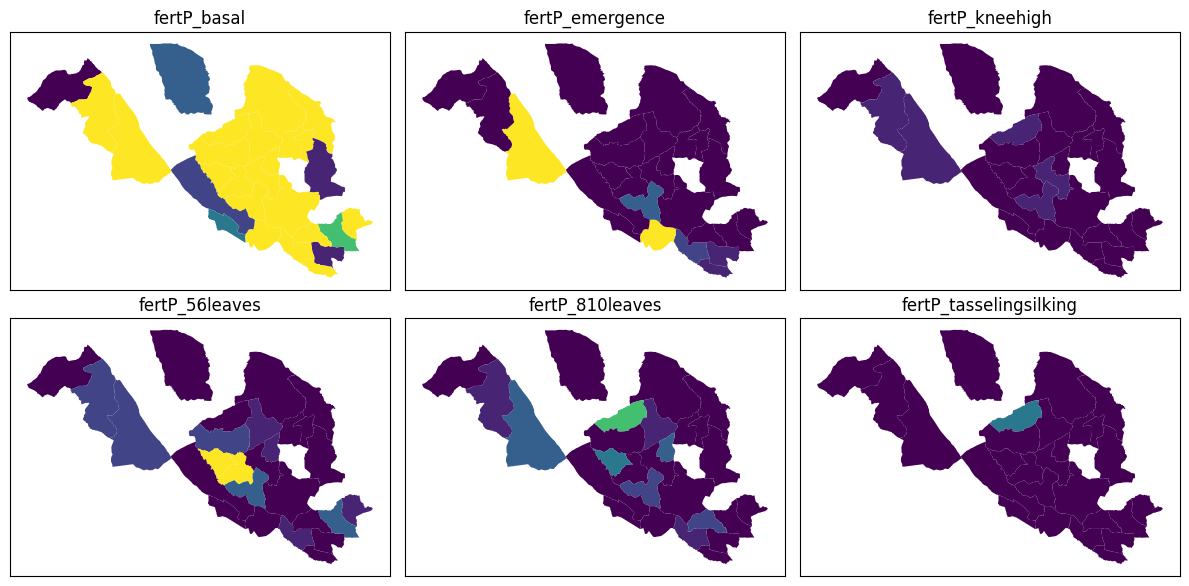

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()
for t, ax in zip(TIMINGS, axes): 
    points['value'] = data[f'fertP_{t}'] > 0
    admin['value'] = admin.ADM3_PCODE.map(points.groupby('ADM3_PCODE')['value'].sum().fillna(0))
    admin.plot('value', ax=ax, vmin=0, vmax=10, cmap='viridis')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'fertP_{t}')
plt.tight_layout()

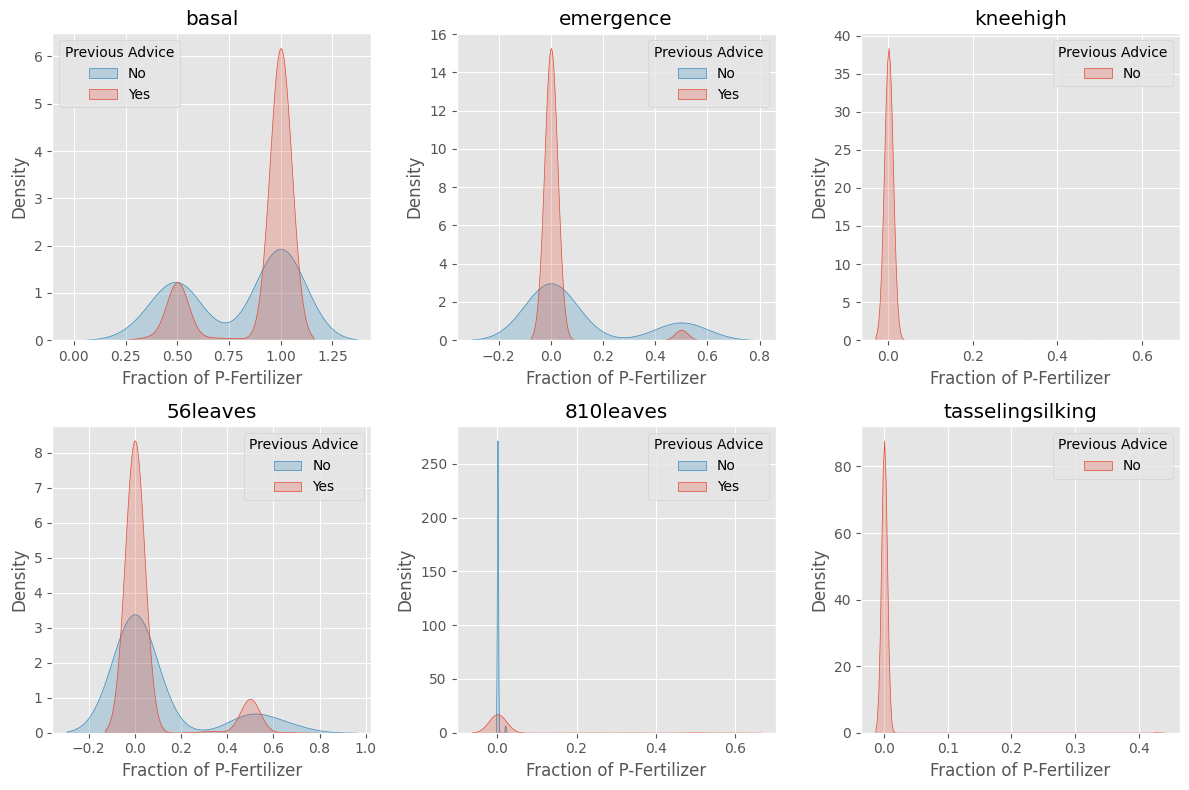

In [75]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for t, ax in zip(TIMINGS, axes):
    sns.kdeplot(
        data=data,
        x=f'fertP_{t}',
        hue='treat_previousadvice',
        fill=True,
        common_norm=False, # Normalize each hue group independently
        ax=ax
    )
    ax.set_title(f'{t}')
    ax.set_xlabel('Fraction of P-Fertilizer')
    ax.set_ylabel('Density')
    ax.legend(title='Previous Advice', labels=['No', 'Yes'])    
plt.tight_layout()

In [19]:
# data[treatment_name] = data[treatment_name] > 0
T_series = data[treatment_name]
Y_series = data[outcome_name]

transformed_data = pd.DataFrame(index=data.index)
# Normalize features
numeric_features = list(data[features].select_dtypes(include='number').columns)
dummy_features = list((data.loc[:, data.isin([0, 1]).all()].columns))

timing_features = [f'fertP_{t}' for t in TIMINGS[:]]

numeric_features = list((set(numeric_features) - set(dummy_features)) - set(timing_features))
transformed_data[numeric_features] = StandardScaler().fit_transform(
    data[numeric_features]
).astype(np.float32)
transformed_data[dummy_features] = data[dummy_features].astype(float)
transformed_data[timing_features] = data[timing_features]

# Transform the outcome crop-wise
tmp_series = data.loc[data.crop_maize, 'outcome_prodkgha']
transformed_data['outcome_prodstd'] = (tmp_series - tmp_series.mean())/tmp_series.std()
tmp_series = data.loc[~data.crop_maize, 'outcome_prodkgha']
transformed_data['outcome_prodstd'] = transformed_data.outcome_prodstd.fillna(
    (tmp_series - tmp_series.mean())/tmp_series.std()
)
# Drop those rows with no production
transformed_data = transformed_data.loc[transformed_data.outcome_prodstd.notna()]
# Drop rows with values not within feasible range
NORMALIZED_LIM = 5
transformed_data = transformed_data.loc[
    (transformed_data < NORMALIZED_LIM).all(axis=1) & 
    (transformed_data > -NORMALIZED_LIM).all(axis=1)
]
# Redefine index of samples
index_zone_subset = transformed_data.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]

In [20]:
# Spatially demean the outcome
spatial_transformer = SpatialTransform(
    points.geometry, maxlag=50e3, esitmator='cressie',
    model='matern', n_lags=50, use_nugget=True
)
spatial_transformer.fit(transformed_data.outcome_prodstd)
transformed_data['outcome_prodstd'] = spatial_transformer.transform_demean()

In [21]:
# Add treatment and Keep only complete records
transformed_data[treatment_name] = data[treatment_name]
transformed_data = transformed_data.dropna()
index_zone_subset = transformed_data.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]

In [22]:
transformed_data.describe().transpose().sort_index()

,count,mean,std,min,25%,50%,75%,max
0to100perc_season_prec,706.0,0.012235,0.910309,-2.636744,-0.601660,-0.005523,0.656893,3.011285
0to100perc_season_rainydays,706.0,-0.001633,0.838751,-2.698515,-0.549929,0.106597,0.561700,2.042587
0to100perc_season_srad,706.0,0.041259,0.880510,-2.902469,-0.424064,0.086684,0.556956,2.565568
0to100perc_season_tmean,706.0,-0.058658,0.929838,-4.582335,-0.732423,-0.056995,0.580114,2.421675
0to10perc_season_prec,706.0,-0.141159,0.911241,-2.367269,-0.840328,-0.200183,0.406315,4.016946
...,...,...,...,...,...,...,...,...
soilpp_density,706.0,-0.036574,0.943606,-4.316240,-0.583618,-0.006196,0.612471,2.695316
soilpp_sand,706.0,-0.042647,0.989681,-2.202656,-0.769008,-0.297174,0.573903,3.023808
treat_previousadvice,706.0,0.059490,0.236707,0.000000,0.000000,0.000000,0.000000,1.000000
variety_hybrid,706.0,0.033994,0.181343,0.000000,0.000000,0.000000,0.000000,1.000000


# Effect of the fertilizer

## Generalized propensity score

In [23]:
x_names = timing_features
w_names = list(set(features) - set(x_names))

training_idxs, testing_idxs = train_test_split(index_zone_subset, random_state=RANDOM_SEED)
print(f"{len(training_idxs)} training samples")
print(f"{len(testing_idxs)} testing samples")
print(f'N features: {len(x_names)+len(w_names)}')

529 training samples
177 testing samples
N features: 92


In [24]:
# First we need a model for the treatment
X_train = transformed_data.loc[training_idxs, w_names + x_names]
t_train = transformed_data.loc[training_idxs, treatment_name]

optimizer_treatment = GPOptimizer(
    model=GradientBoostingRegressor,
    model_kwargs=dict(
        max_depth=Integer(name='max_depth', low=2, high=6),
        # max_features=Categorical(name='max_features', categories=['sqrt', 'log2']),
        # min_samples_leaf=Integer(name='min_samples_leaf', low=1, high=50),
        learning_rate=Real(name='learning_rate', low=1e-3, high=1), 
        n_estimators=1000, n_iter_no_change=20, max_features='sqrt',
        random_state=RANDOM_SEED
    )
)
model_treatment, cv_scores_treatment = optimizer_treatment.cv_optimize(
    X_train, t_train,
    cv=5,
    cv_kwargs=dict(n_jobs=-1, scoring='r2'),
    gp_kwargs=dict(n_calls=50, n_initial_points=5, verbose=False, random_state=RANDOM_SEED)
)

In [25]:
model_treatment = model_treatment.fit(X_train, t_train)
test_score = r2_score(
    y_true=transformed_data.loc[testing_idxs, treatment_name],
    y_pred=model_treatment.predict(transformed_data.loc[testing_idxs, w_names + x_names])
)
print(f'CV R2 mean: {np.mean(cv_scores_treatment):.3f}')
print(f'Test R2: {test_score:.3f}')
print(f'Train R2: {r2_score(t_train, model_treatment.predict(X_train)):.3f}')

CV R2 mean: 0.790
Test R2: 0.756
Train R2: 0.952


In [26]:
pd.Series(
    model_treatment.feature_importances_,
    index=features
).sort_values(ascending=False).head(10)

50to60perc_season_prec          0.188685
90to100perc_season_rainydays    0.184408
accessibility_rai               0.043722
fertN_total                     0.039150
history_maize                   0.034104
fertP_56leaves                  0.031544
90to100perc_season_tmean        0.030937
soilpp_sand                     0.027874
80to90perc_season_prec          0.027732
10to20perc_season_tmean         0.025126
dtype: float64

<Axes: ylabel='Count'>

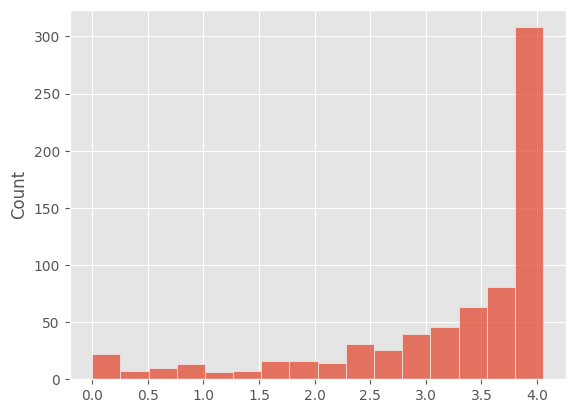

In [27]:
# Use Zhu et al. (2018) and Hirano and Gimbens (2004) approach to estimate PS for continuous treatments
from scipy import stats
T = transformed_data.loc[:, treatment_name].values
# Get the CV predictions to estimate the variance of residuals
T_pred = cross_val_predict(
    model_treatment, 
    X=transformed_data.loc[:, w_names + x_names],
    y=transformed_data.loc[:, treatment_name]
)
T_res = T - T_pred
res_var = np.var(T_res)

# Estimate the GPS
# gps = (1/(np.sqrt(2*np.pi*res_var)))*np.exp((-1/(2*res_var))*treatment_res**2)
gps_density = stats.norm.pdf(
    T, 
    loc=T_pred, 
    scale=res_var**.5 # Scale is sd in this function
)
plt.style.use('ggplot')
sns.histplot(gps_density)

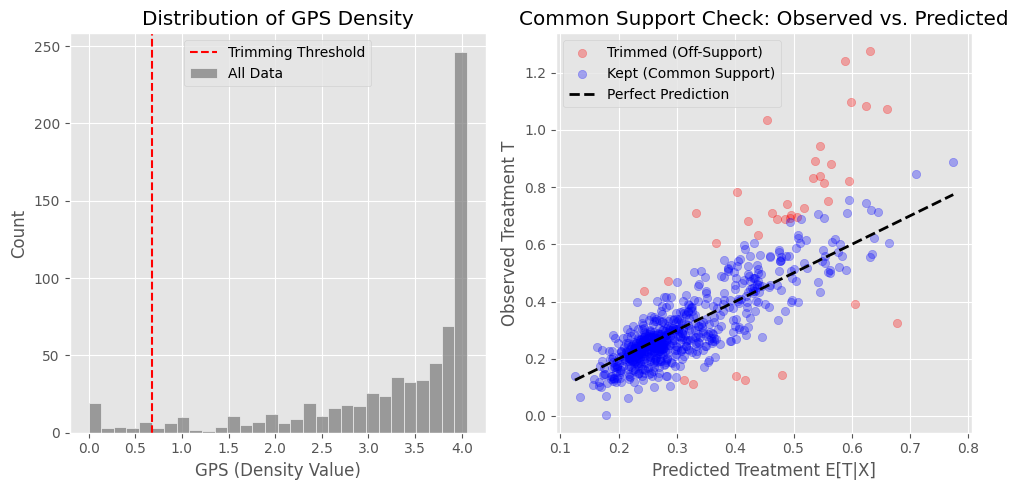

In [28]:
threshold = np.quantile(gps_density, 0.05)
mask_support = gps_density >= threshold
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
ax = axes[0]

sns.histplot(gps_density, bins=30, ax=axes[0], color='grey', label='All Data')
ax.axvline(threshold, color='red', linestyle='--', label='Trimming Threshold')
ax.set_title("Distribution of GPS Density")
ax.set_xlabel("GPS (Density Value)")
ax.legend()


ax = axes[1]
ax.scatter(T_pred[~mask_support], T[~mask_support], alpha=0.3, color='red', label='Trimmed (Off-Support)')
ax.scatter(T_pred[mask_support], T[mask_support], alpha=0.3, color='blue', label='Kept (Common Support)')
ax.plot([min(T_pred), max(T_pred)], [min(T_pred), max(T_pred)], 'k--', lw=2, label='Perfect Prediction')

ax.set_title("Common Support Check: Observed vs. Predicted")
ax.set_xlabel("Predicted Treatment E[T|X]")
ax.set_ylabel("Observed Treatment T")
ax.legend()

plt.tight_layout()
plt.show()

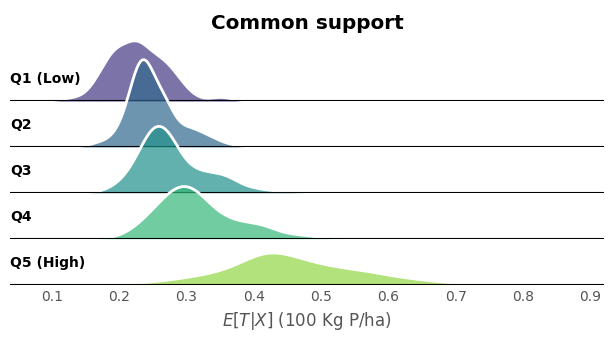

In [29]:
tmp_df = pd.DataFrame({'T_pred': T_pred[mask_support], 'Strata': pd.qcut(T[mask_support], 5, labels=False)})

g = sns.FacetGrid(tmp_df, row="Strata", hue="Strata", aspect=9, height=.75, palette="viridis")
g.map(sns.kdeplot, "T_pred", clip_on=False, fill=True, alpha=0.7, lw=0)
g.map(sns.kdeplot, "T_pred", clip_on=False, color="w", lw=2)

g.fig.subplots_adjust(hspace=-.5)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
g.axes.flat[0].set_title("Common support", fontweight='bold', y=.7) 
g.axes.flat[-1].set_xlabel(r'$E[T|X]$'+' (100 Kg P/ha)')

# Optional: Add text labels for each stratum
for ax, label in zip(g.axes.flat, ["Q1 (Low)", "Q2", "Q3", "Q4", "Q5 (High)"]):
    ax.text(0, 0.2, label, fontweight="bold", transform=ax.transAxes)
    ax.axhline(0, color='k', linestyle="-")
    ax.set_facecolor('none')
    ax.grid(None)
    ax.tick_params(length=0)

<Axes: ylabel='Density'>

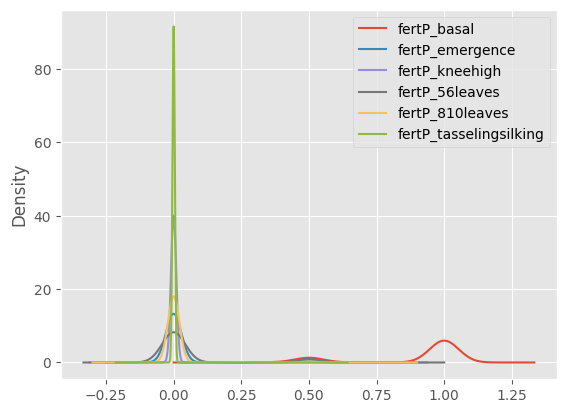

In [30]:
# Check the distribution of timing to select only those that have a good distribution
transformed_data.loc[:, timing_features].plot.kde()

In [31]:
# Trim extreme residuals
transformed_data_pstrimmed = transformed_data.copy()
transformed_data_pstrimmed = transformed_data_pstrimmed.loc[gps_density > threshold]

In [32]:
transformed_data_pstrimmed = transformed_data.copy()
index_zone_subset = transformed_data_pstrimmed.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]
transformed_data_pstrimmed.shape

(706, 94)

## Outcome model $q(X, W)$

In [33]:
y_train = transformed_data_pstrimmed.loc[training_idxs, outcome_name]

optimizer_q = GPOptimizer(
    model=RandomForestRegressor,
    model_kwargs=dict(
        max_depth=Integer(name='max_depth', low=2, high=10),
        max_features=Categorical(name='max_features', categories=['sqrt', 'log2']),
        min_samples_leaf=Integer(name='min_samples_leaf', low=1, high=50),
        n_estimators=100, random_state=RANDOM_SEED
    )
)

# optimizer_q = GPOptimizer(
#     model=GradientBoostingRegressor,
#     model_kwargs=dict(
#         max_depth=Integer(name='max_depth', low=2, high=6),
#         # max_features=Categorical(name='max_features', categories=['sqrt', 'log2']),
#         # min_samples_leaf=Integer(name='min_samples_leaf', low=1, high=50),
#         learning_rate=Real(name='learning_rate', low=1e-3, high=1), 
#         n_estimators=1000, n_iter_no_change=20, max_features='sqrt',
#         random_state=RANDOM_SEED
#     )
# )
model_q, cv_scores_q = optimizer_q.cv_optimize(
    X_train, y_train,
    cv=5,
    cv_kwargs=dict(n_jobs=-1, scoring='r2'),
    gp_kwargs=dict(n_calls=100, n_initial_points=5, verbose=False, random_state=RANDOM_SEED)
)

In [34]:
model_q = model_q.fit(X_train, y_train)
test_score = r2_score(
    y_true=transformed_data_pstrimmed.loc[testing_idxs, outcome_name],
    y_pred=model_q.predict(transformed_data_pstrimmed.loc[testing_idxs, w_names + x_names])
)
print(f'CV R2 mean: {np.mean(cv_scores_q):.3f}')
print(f'Test R2: {test_score:.3f}')
print(f'Train R2: {r2_score(y_train, model_q.predict(X_train)):.3f}')

CV R2 mean: 0.012
Test R2: 0.036
Train R2: 0.092


In [35]:
pd.Series(
    model_q.feature_importances_,
    index=features
).sort_values(ascending=False).head(10)

90to100perc_season_rainydays    0.195885
0to10perc_season_tmean          0.069933
investing_capacity_index        0.046507
phenology_losstd                0.044527
80to90perc_season_tmean         0.039940
80to90perc_season_srad          0.036781
history_nocrop                  0.026592
30to40perc_season_srad          0.024066
soilfert_cec                    0.023117
soilpp_density                  0.021799
dtype: float64

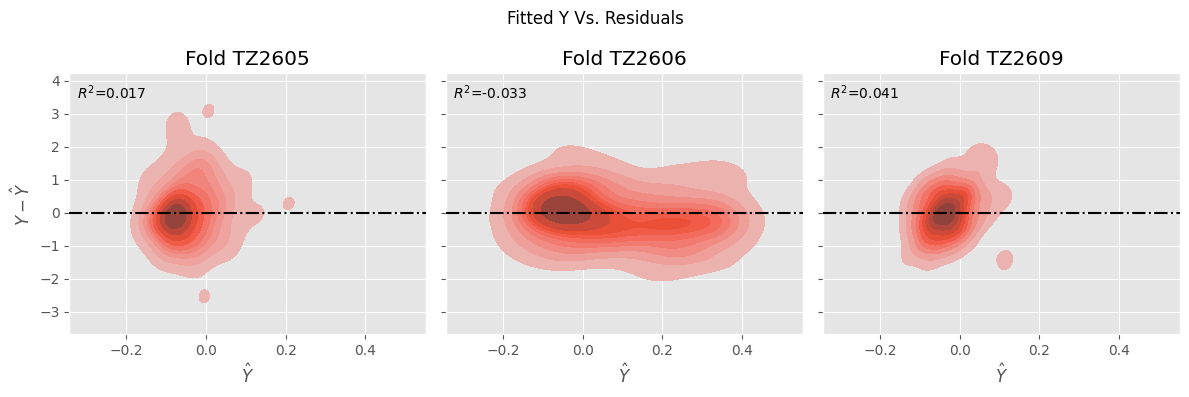

In [36]:
from sklearn.base import clone

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
axes = axes.flatten()
spatial_group = 'ADM2_PCODE'
groups = points[spatial_group].unique()

for n, gr in enumerate(groups):
    ax = axes[n]
    tmp_model = clone(model_q)
    tmp_idx = points.index[points[spatial_group] != gr]
    tmp_X = transformed_data_pstrimmed.loc[tmp_idx, w_names + x_names]
    tmp_y = transformed_data_pstrimmed.loc[tmp_idx, outcome_name]

    tmp_model = tmp_model.fit(tmp_X, tmp_y)

    tmp_idx = points.index[points[spatial_group] == gr]
    tmp_X = transformed_data_pstrimmed.loc[tmp_idx, w_names + x_names]
    tmp_y = transformed_data_pstrimmed.loc[tmp_idx, outcome_name]
    y_pred = tmp_model.predict(tmp_X)

    sns.kdeplot(
        x=y_pred, 
        y= tmp_y - y_pred,
        ax=ax,
        zorder=2, fill=True
    )
    
    ax.set_title(f'Fold {gr}')
    ax.axhline(0, color='k', zorder=3, linestyle='-.')
    ax.set_xlabel(r"$\hat{Y}$")
    ax.set_ylabel(r"$Y - \hat{Y}$")
    ax.text(
        0.02, 0.90, r'$R^2$='+f'{r2_score(tmp_y, y_pred):.3f}',
        transform=ax.transAxes
    )
fig.suptitle('Fitted Y Vs. Residuals')
plt.tight_layout()

## DML 

In [37]:
from econml.dml import LinearDML, SparseLinearDML, CausalForestDML
from econml.inference import BootstrapInference
N_BOOTSTRAP = 100
bootstrap = BootstrapInference(N_BOOTSTRAP, bootstrap_type='percentile')

### Homogeneous effect

In [38]:
W = transformed_data_pstrimmed.loc[:,features]
Y = transformed_data_pstrimmed.loc[:, outcome_name].to_numpy()
T = transformed_data_pstrimmed.loc[:, treatment_name].to_numpy()

lineardml_hom_estimate = LinearDML(
    model_y=model_q, 
    model_t=model_treatment, 
    discrete_treatment=False,
    cv=5,
    random_state=RANDOM_SEED
)
lineardml_hom_estimate = lineardml_hom_estimate.fit(
    Y=Y, T=T, W=W,
    inference=bootstrap, cache_values=True
)

In [39]:
lineardml_hom_estimate.ate_inference()

### Heterogeneous effect

In [40]:
W = transformed_data_pstrimmed.loc[:, list(set(features) - set(x_names))].to_numpy()
X = transformed_data_pstrimmed.loc[:, x_names].to_numpy()
Y = transformed_data_pstrimmed.loc[:, outcome_name].to_numpy()
T = transformed_data_pstrimmed.loc[:, treatment_name].to_numpy()

cf_estimator = CausalForestDML(
    model_y=model_q, 
    model_t=model_treatment, 
    discrete_treatment=False,
    cv=5, 
    random_state=RANDOM_SEED,
    fit_intercept=True,
    # Trees hyperparameters 
    criterion='het',
    # min_balancedness_tol=0.45
)
cf_estimator = cf_estimator.fit(
    Y=Y, T=T, X=X, W=W, 
    inference=bootstrap, cache_values=True
)
cf_estimator.score_

In [41]:
cf_estimator.ate_inference(X)

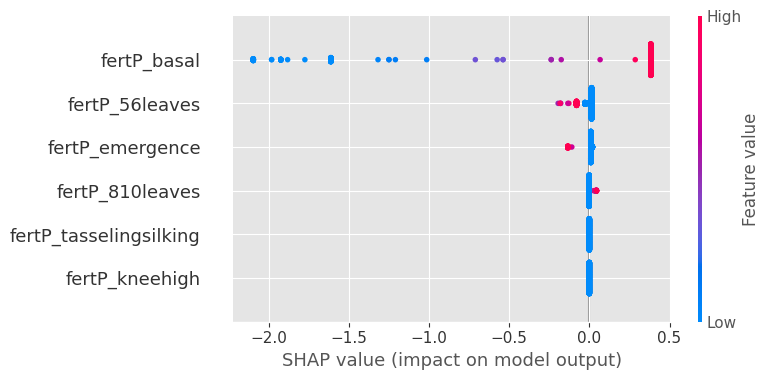

In [42]:
import shap

shap_values = cf_estimator.shap_values(X)
shap.summary_plot(shap_values['Y0']['T0'], feature_names=x_names)

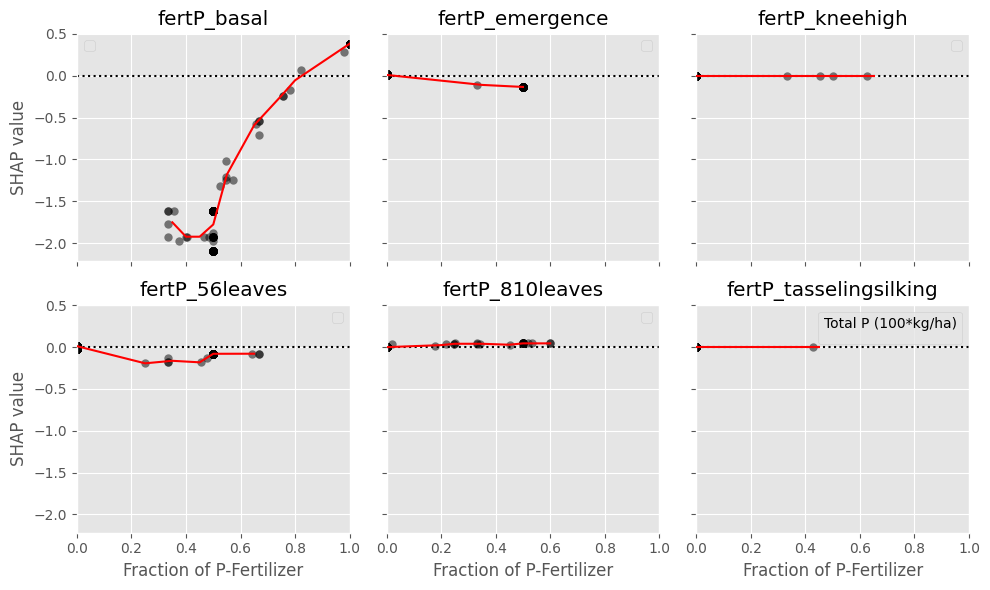

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharex=True, sharey=True)
axes = axes.flatten()
for n, x_n in enumerate(x_names):
    ax = axes[n]
    sns.scatterplot(
        x=shap_values['Y0']['T0'].data[:, n],
        y=shap_values['Y0']['T0'].values[:, n],
        # hue=T, palette='inferno', 
        color='k', alpha=.5,
        ax=ax, linewidth=0, zorder=2,
    )
    x = np.round(shap_values['Y0']['T0'].data[:, n]*20)/20
    # sns.regplot(
    #     x=shap_values['Y0']['T0'].data[:, n],
    #     y=shap_values['Y0']['T0'].values[:, n],
    #     ax=ax, lowess=True, marker='.',
    #     line_kws=dict(color='k'),
    #     scatter_kws=dict(linewidths=0)
    # )
    sns.lineplot(
        x=np.round(shap_values['Y0']['T0'].data[:, n]*20)/20,
        y=shap_values['Y0']['T0'].values[:, n], zorder=3,
        ax=ax, color='r', errorbar=None
    )

    ax.set_title(x_n)
    ax.set_xlabel('Fraction of P-Fertilizer')
    ax.set_ylabel('SHAP value')
    ax.set_xlim(0, 1)
    ax.axhline(0, linestyle=':', color="k", zorder=1)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend('')
ax.legend(handles, labels, ncols=2, title='Total P (100*kg/ha)')

plt.tight_layout()


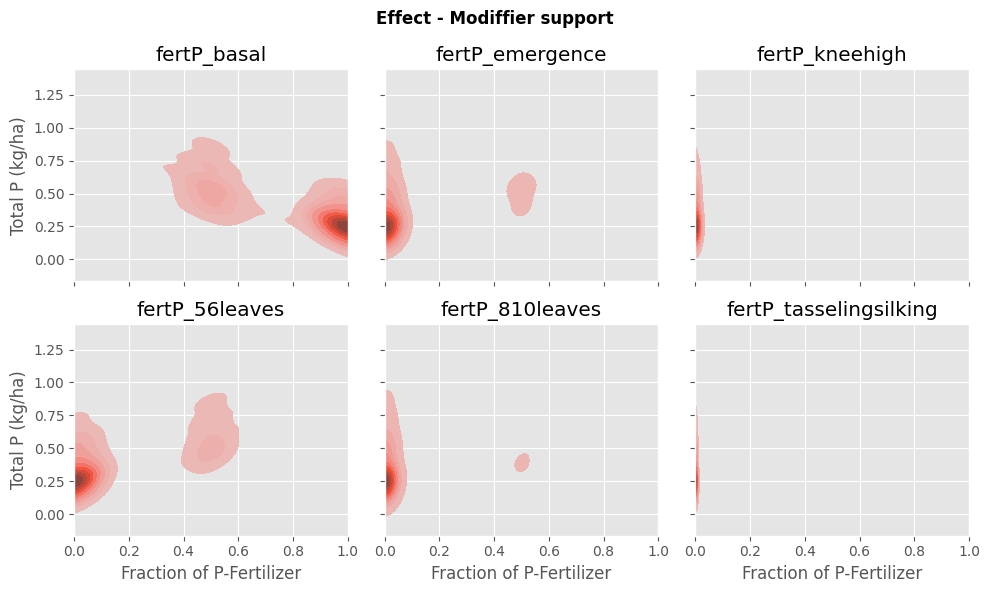

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharex=True, sharey=True)
axes = axes.flatten()
for n, x_n in enumerate(x_names):
    ax = axes[n]
    sns.kdeplot(
        transformed_data_pstrimmed,
        x=x_n,
        y=treatment_name, 
        fill=True, ax=ax
    )
    ax.set_title(x_n)
    ax.set_xlim(0, 1)
    ax.set_xlabel('Fraction of P-Fertilizer')
    ax.set_ylabel('Total P (kg/ha)')
plt.suptitle('Effect - Modiffier support', fontweight='bold')
plt.tight_layout()

In [45]:
# Shap values of individual estimators
from tqdm import tqdm

shap_values_instances = []
for est_instance in tqdm(cf_estimator._inference._est._instances):
    shap_values_instances.append(est_instance.shap_values(X))

100%|██████████| 100/100 [00:11<00:00,  8.52it/s]


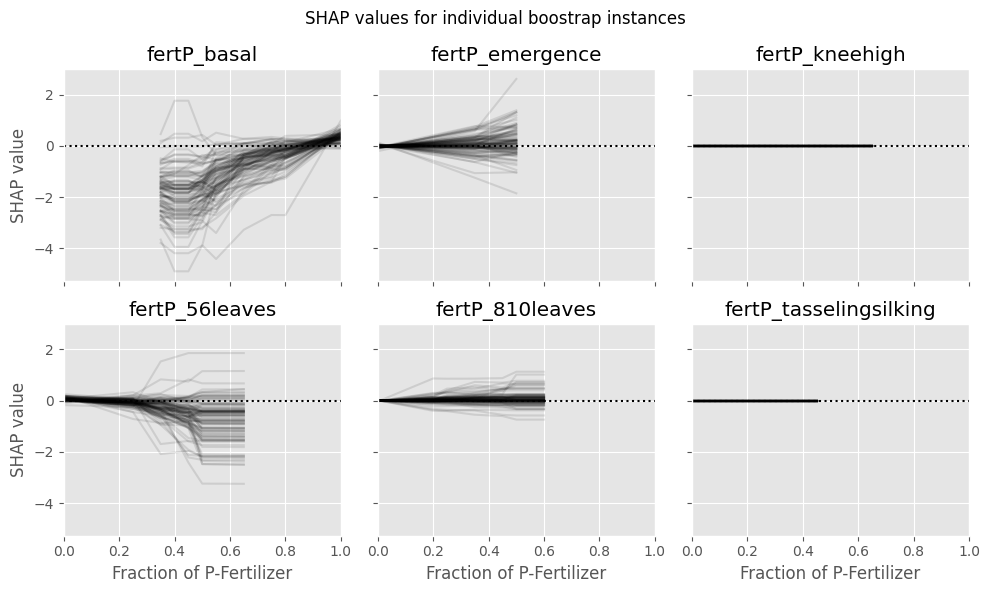

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharex=True, sharey=True)
axes = axes.flatten()
for n, x in enumerate(x_names):
    ax = axes[n]
    for shap_vals in shap_values_instances:
        sns.lineplot(
            x=np.round(shap_vals['Y0']['T0'].data[:, n]*20)/20,
            y=shap_vals['Y0']['T0'].values[:, n],
            ax=ax, color='k', errorbar=None, alpha=.1
        )
    ax.set_title(x)
    ax.set_xlabel('Fraction of P-Fertilizer')
    ax.set_ylabel('SHAP value')
    ax.set_xlim(0, 1)
    ax.axhline(0, linestyle=':', color="k", zorder=1)
fig.suptitle('SHAP values for individual boostrap instances')
plt.tight_layout()


Text(50.722222222222214, 0.5, '810Leaves application as % of total')

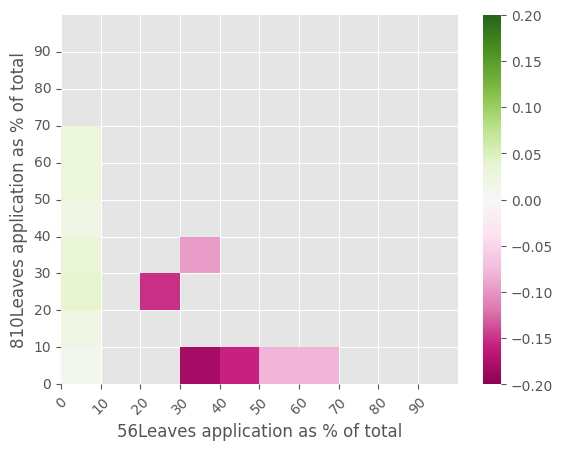

In [47]:
shap_cmap = mpl.colors.LinearSegmentedColormap.from_list("", ['#f4006e','#008bfb'])

def shap_interaction_array(x0, x1, bins=np.linspace(0.025, .975, 20)):
    res = bins[1:] - bins[:-1]
    res = res.mean()/2

    x=shap_values['Y0']['T0'].data[:, x0]
    y=shap_values['Y0']['T0'].data[:, x1]
    z=shap_values['Y0']['T0'].values[:, [x0, x1]].sum(axis=1)
    zz = np.ones(shape=(len(bins), len(bins)))

    for i, y_i in enumerate(bins):
        y_mask = (y >= y_i-res) & (y <= y_i +res)
        for j, x_j in enumerate(bins):
            x_mask = (x >= x_j-res) & (x <= x_j +res)
            zz[i][j] = z[y_mask & x_mask].mean()
    return zz[::-1]

fig, ax = plt.subplots()   
bins = np.linspace(0.05, .95, 10)
x0 = 3; x1 = 4
zz = shap_interaction_array(x0, x1, bins)
sns.heatmap(
    zz, cmap='PiYG', ax=ax, vmin=-0.2, vmax=0.2
)
ax.set_xticks(ax.get_xticks()-.5); ax.set_yticks(ax.get_yticks()+.5)
ax.set_xticklabels([f'{b*100:.0f}' for b in bins-.05], rotation=45)
ax.set_yticklabels([f'{b*100:.0f}' for b in bins-.05][::-1], rotation=0)
ax.set_xlabel(f'{TIMINGS[x0].title()} application as % of total')
ax.set_ylabel(f'{TIMINGS[x1].title()} application as % of total')

In [48]:
maize_std = clean_data.loc[index_zone_subset].maizeprodkg_ha.std()
soya_std = clean_data.loc[index_zone_subset].soyaprodkg_ha.std()
maize_std * np.array([cf_estimator.ate(X), lineardml_hom_estimate.ate()])/100

array([47.82024464, 34.92399379])

In [49]:
np.array(cf_estimator.nuisance_scores_).mean(axis=2), np.array(cf_estimator.nuisance_scores_).std(axis=2)

(array([[0.01553838],
        [0.76582828]]),
 array([[0.01188314],
        [0.02550677]]))

## Sensitivity analysis

In [50]:
cf_estimator.sensitivity_summary()

<class 'econml.utilities.Summary'>
"""
Sensitivity Analysis Summary for c_y=0.05, c_t=0.05, rho=1.0
===============================================
CI Lower Theta Lower Theta Theta Upper CI Upper
-----------------------------------------------
   0.769        1.53 1.997       2.465    3.203
   Robustness Values for null_hypothesis=0    
==============================================
Robustness Value (Theta) Robustness Value (CI)
----------------------------------------------
                   0.196                 0.124
----------------------------------------------
"""

## Placebo test

In [51]:
placebo_estimates = []
placebo_shaps = []

for _ in tqdm(range(N_BOOTSTRAP)):
    T_placebo = np.random.choice(T, size=len(T), replace=True)

    cf_placebo_estimator = CausalForestDML(
        model_y=model_q, 
        model_t=model_treatment, 
        discrete_treatment=False,
        cv=5, 
        random_state=RANDOM_SEED,
        fit_intercept=True,
        # Trees hyperparameters 
        criterion='het',
        # min_balancedness_tol=0.45
    )
    cf_placebo_estimator = cf_placebo_estimator.fit(
        Y=Y, T=T_placebo, X=X, W=W, 
        inference=None, cache_values=True
    )
    placebo_estimates.append((
        cf_placebo_estimator.ate(X),
    ))
    placebo_shaps.append(cf_placebo_estimator.shap_values(X))

100%|██████████| 100/100 [01:27<00:00,  1.14it/s]


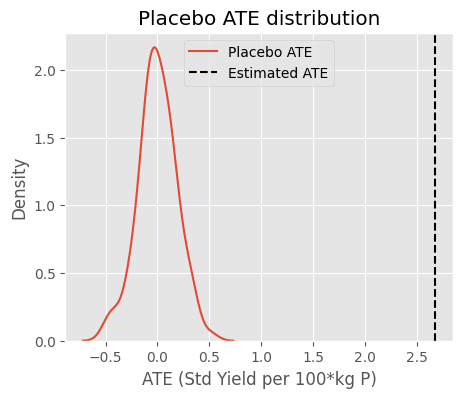

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sns.kdeplot(np.array(placebo_estimates).flatten(), label='Placebo ATE')
ax.set_xlabel('ATE (Std Yield per 100*kg P)')
ax.set_title('Placebo ATE distribution')
ax.axvline(cf_estimator.ate(X), label='Estimated ATE', color='k', linestyle='--')
ax.legend()

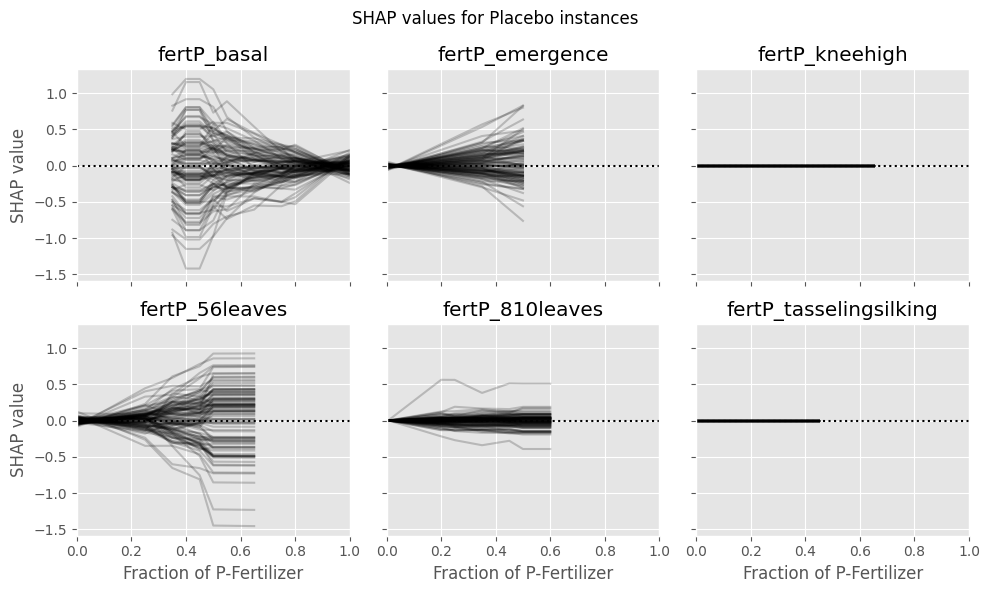

In [53]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharex=True, sharey=True)
axes = axes.flatten()
for n, x in enumerate(x_names):
    ax = axes[n]
    for shap_vals in placebo_shaps:
        sns.lineplot(
            x=np.round(shap_vals['Y0']['T0'].data[:, n]*20)/20,
            y=shap_vals['Y0']['T0'].values[:, n],
            ax=ax, color='k', errorbar=None, alpha=.2
        )
    ax.set_title(x)
    ax.set_xlabel('Fraction of P-Fertilizer')
    ax.set_ylabel('SHAP value')
    ax.set_xlim(0, 1)
    ax.axhline(0, linestyle=':', color="k", zorder=1)
fig.suptitle('SHAP values for Placebo instances')
plt.tight_layout()


In [55]:
from statsmodels.api import OLS

ols_model = OLS(
    endog=transformed_data_pstrimmed[outcome_name],
    exog=transformed_data_pstrimmed[[treatment_name] + w_names],
).fit()
# ols_model = ols(
#     data=transformed_data_pstrimmed,
#     formula=f'{outcome_name} ~ {treatment_name} + ' + '+'.join(w_names)
# ).fit()
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        outcome_prodstd   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.139
Method:                 Least Squares   F-statistic:                     2.333
Date:                Thu, 04 Dec 2025   Prob (F-statistic):           3.60e-09
Time:                        15:12:36   Log-Likelihood:                -707.46
No. Observations:                 706   AIC:                             1587.
Df Residuals:                     620   BIC:                             1979.
Df Model:                          85                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
fertP_total                      0.7178      0.246      2.917      0.004       0.234       1.201
0to100perc_season_srad           0.1985      2.639      0.075      0.940      -4.983       5.380
neighbor_previousadvice_avg     -0.0687      0.050     -1.372      0.170      -0.167       0.030
70to80perc_season_prec           0.8427      0.605      1.394      0.164      -0.345       2.030
90to100perc_season_tmean         0.9960      1.250      0.797      0.426      -1.460       3.452
fertN_56leaves                 8.92e+05   9.46e+05      0.943      0.346   -9.66e+05    2.75e+06
history_oilseed                 -0.5165      0.757     -0.682      0.495      -2.003       0.970
fertN_kneehigh                7.254e+05   7.69e+05      0.943      0.346   -7.85e+05    2.24e+06
10to20perc_season_rainydays     -0.6197      0.451     -1.374      0.170      -1.506       0.266
elevation_value                  0.1353      0.085      1.592      0.112      -0.032       0.302
lon                              0.3367      0.156      2.152      0.032       0.029       0.644
30to40perc_season_tmean          0.3282      0.883      0.372      0.710      -1.406       2.063
70to80perc_season_srad          -0.0018      0.612     -0.003      0.998      -1.204       1.201
history_nocrop                  -0.3117      0.245     -1.272      0.204      -0.793       0.169
60to70perc_season_prec           2.5877      1.531      1.691      0.091      -0.418       5.594
80to90perc_season_tmean          0.8084      1.306      0.619      0.536      -1.757       3.374
20to30perc_season_srad          -0.1397      0.936     -0.149      0.881      -1.978       1.699
herbicide_any                    0.1491      0.155      0.964      0.335      -0.155       0.453
treat_previousadvice            -0.1776      0.130     -1.369      0.172      -0.432       0.077
history_rootandtuber            -0.1121      0.324     -0.346      0.729      -0.748       0.524
phenology_losstd                -0.0578      0.166     -0.348      0.728      -0.384       0.269
0to10perc_season_tmean           0.7065      1.226      0.576      0.565      -1.702       3.115
fieldsize_value                  0.0912      0.084      1.085      0.278      -0.074       0.256
0to10perc_season_rainydays      -1.1316      0.709     -1.597      0.111      -2.523       0.260
variety_hybrid                  -0.1742      0.199     -0.876      0.381      -0.565       0.216
planting_ploughsowing            0.1287      0.382      0.337      0.736      -0.621       0.878
residue_burn                    -0.2921      0.242     -1.206      0.228      -0.768       0.184
80to90perc_season_prec           0.3965      0.247      1.604      0.109      -0.089       0.882
fertN_emergence               3.778e+05   4.01e+05      0.943      0.346   -

In [56]:
0.7178/100 * maize_std

In [68]:
timing_options = []

perc = np.arange(0, 30, 10)/100
for v56 in perc:
    for v810 in perc:
        if v56 + v810 > 1:
            continue
        timing_options.append((v56, v810))

def get_best_splitting(est):
    best = None
    ci_low = -99
    for op in timing_options:
        op = np.array(op)
        op = (1-sum(op), 0, 0, op[0], op[1], 0)
        ci = est.ate_interval([op])
        if ci[0] > ci_low:
            ci_best = ci
            ci_low = ci[0]
            best = op
    return (*best, *ci_best)

len(timing_options)

In [69]:
def to_pct_10(X):
    res = (X * 10).astype(int)
    k = 10 - res.sum()
    res[np.argsort(X * 10 - res)[res.size - k:]] += 1
    return res * 10

In [59]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

X_trans = np.sqrt(X)

dbscan = DBSCAN(eps=np.sqrt(.01), min_samples=20) 
appl_clusters_df = pd.DataFrame(X, columns=x_names)
appl_clusters_df['cluster'] = dbscan.fit_predict(X_trans)
appl_clusters_df['Cluster name'] = appl_clusters_df['cluster'].map({
    -1: 'Noise',
    0: '100% Basal',
    1: '50% Basal, 50% Emergence',
    2: '50% Basal, 50% V5-6',
})
(appl_clusters_df.groupby('Cluster name').agg(('mean' , 'std'))*100).astype(int)

# (appl_clusters_df.groupby('cluster').agg(('mean' , 'std'))*100).astype(int)

fertP_basal     fertP_emergence     fertP_kneehigh  \
                                mean std            mean std           mean   
Cluster name                                                                  
100% Basal                       100   0               0   0              0   
50% Basal, 50% Emergence          50   0              50   0              0   
50% Basal, 50% V5-6               50   0               0   0              0   
Noise                             53  15               0   5              5   

                             fertP_56leaves     fertP_810leaves      \
                         std           mean std            mean std   
Cluster name                                                          
100% Basal                 0              0   0               0   0   
50% Basal, 50% Emergence   0              0   0               0   0   
50% Basal, 50% V5-6        0             49   0               0   0   
Noise                     16              9  20              29  22   

                         fertP_tasselingsilking     cluster      
                                           mean std    mean std  
Cluster name                                                     
100% Basal                                    0   0       0   0  
50% Basal, 50% Emergence                      0   0     100   0  
50% Basal, 50% V5-6                           0   0     200   0  
Noise                                         1   7    -100   0

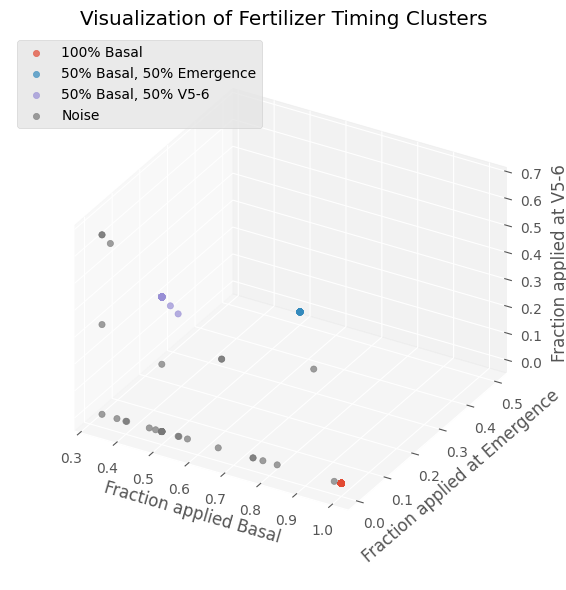

In [61]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6), subplot_kw={'projection': '3d'})

for cluster in np.unique(appl_clusters_df['Cluster name']):
    # if cluster == 'Noise':
    #     continue
    x = appl_clusters_df.loc[appl_clusters_df['Cluster name'] == cluster, 'fertP_basal']
    y = appl_clusters_df.loc[appl_clusters_df['Cluster name'] == cluster, 'fertP_emergence']
    z = appl_clusters_df.loc[appl_clusters_df['Cluster name'] == cluster, 'fertP_56leaves']
    ax.scatter(x, y, z, label=f'{cluster}', alpha=0.7)

ax.set_proj_type('ortho')
ax.set_facecolor('white')
ax.set_title("Visualization of Fertilizer Timing Clusters")

ax.set_xlabel('Fraction applied Basal')
ax.set_ylabel('Fraction applied at Emergence')
ax.set_zlabel('Fraction applied at V5-6')
ax.legend(loc='upper left')
ax.set_box_aspect(None, zoom=0.9)
fig.tight_layout()

In [62]:
appl_clusters_df['Cluster name'].value_counts()

Cluster name
100% Basal                  565
50% Basal, 50% V5-6          74
Noise                        34
50% Basal, 50% Emergence     33
Name: count, dtype: int64

In [63]:
# Estimate the ATE for each cluster
clusters = appl_clusters_df.cluster.values
cluster_names = appl_clusters_df['Cluster name'].values
cluster_names_unique = appl_clusters_df['Cluster name'].unique()

inferences_dict = {}
for n, ap in enumerate(cluster_names_unique):
    if ap == 'Noise':
        continue
    print(ap)
    mask = cluster_names == ap 
    inferences_dict[ap] = cf_estimator.ate_inference(X[mask])

100% Basal
50% Basal, 50% Emergence
50% Basal, 50% V5-6


,value,ci_low,ci_high
100% Basal,55.373194,28.545729,82.200658
"50% Basal, 50% Emergence",15.217696,-19.516794,49.952185
"50% Basal, 50% V5-6",18.446283,-2.654641,39.547206


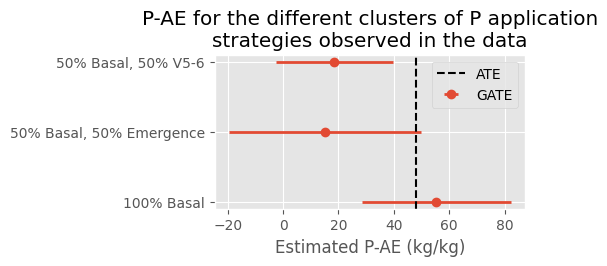

In [69]:

tmp_df = pd.DataFrame(columns=['value', 'ci_low', 'ci_high'], index=inferences_dict.keys())
for ap, infer in inferences_dict.items():
    tmp_df.loc[ap] = infer.mean_point, *infer.conf_int_mean()

tmp_df *= maize_std/100 # Convert to N-AE

fig, ax = plt.subplots(1, 1, figsize=(4, 2))
ax.errorbar(
    y=tmp_df.index,
    x=tmp_df['value'],
    xerr=np.abs(tmp_df[['ci_low', 'ci_high']].values.T - tmp_df['value'].values),
    fmt='o', linewidth=2, label='GATE'
)
ax.set_xlabel('Estimated P-AE (kg/kg)')
# ax.set_ylim(-0.5, 4.5)
ax.set_title('P-AE for the different clusters of P application\nstrategies observed in the data')
# plt.tight_layout()
ax.axvline(cf_estimator.ate(X) * maize_std/100, color='k', linestyle='--', label='ATE')
ax.legend()
tmp_df

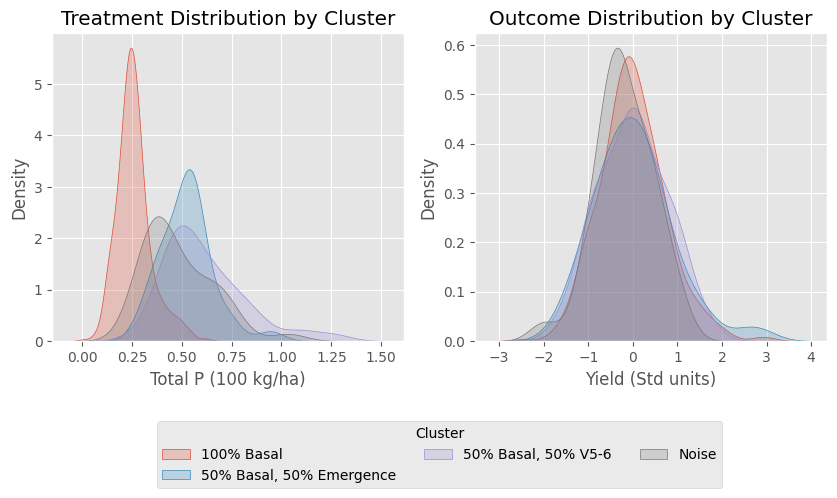

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for c in np.unique(cluster_names_unique):
    if c == -1:
        continue
    ax = axes[0]
    sns.kdeplot(
        x=T[cluster_names==c],
        fill=True, ax=ax,
        label=f'{c}'
    )
    ax.set_title('Treatment Distribution by Cluster')
    ax.set_xlabel('Total P (100 kg/ha)')

    ax = axes[1]
    sns.kdeplot(
        x=Y[cluster_names==c],
        fill=True, ax=ax,
        label=f'{c}'
    )
    ax.set_title('Outcome Distribution by Cluster')
    ax.set_xlabel('Yield (Std units)')

ax.legend(loc='lower center', bbox_to_anchor=(-0.1, -0.5, 0., .0), ncol=3, title='Cluster')

In [72]:
appl_clusters_df['Outcome'] = Y
appl_clusters_df['Treatment'] = T

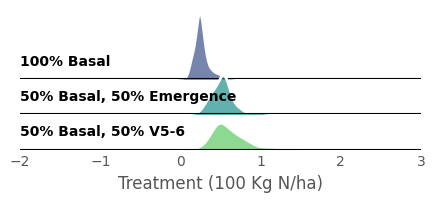

In [73]:
g = sns.FacetGrid(
    appl_clusters_df.loc[appl_clusters_df['Cluster name'] != 'Noise'], 
    row="Cluster name", hue="Cluster name", aspect=6, 
    height=.8, palette="viridis"
)
g.map(sns.kdeplot, "Treatment", fill=True, alpha=0.7, lw=0)
g.map(sns.kdeplot, "Treatment", color="w", lw=2)
g.fig.subplots_adjust(hspace=-.5)
g.set_titles("")
g.set(yticks=[], ylabel="")
# g.set(xticks=[0])
g.despine(bottom=True, left=True)
# g.axes.flat[0].set_title("Common support", fontweight='bold', y=.7) 
g.axes.flat[-1].set_xlabel('Treatment (100 Kg N/ha)')
# Optional: Add text labels for each stratum

for ax, label in zip(g.axes.flat, appl_clusters_df.loc[appl_clusters_df['Cluster name'] != 'Noise']['Cluster name'].unique()):
    ax.text(0, 0.2, label, fontweight="bold", transform=ax.transAxes)
    ax.axhline(0, color='k', linestyle="-")
    ax.set_facecolor('none')
    ax.grid(None)
    ax.tick_params(length=0)
    ax.set_xlim(-2, 3)
# g.fig.suptitle(f'{zone} zone, {treatment} treatment', fontweight='bold')